In [73]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/sf-booking/hotels_test.csv
/kaggle/input/competitions/sf-booking/hotels_train.csv
/kaggle/input/competitions/sf-booking/submission.csv


# Прогнозирование рейтинга отелей (Booking.com)

## Описание задачи
Цель – построить модель, предсказывающую рейтинг отеля (`reviewer_score`) на основе отзывов и метаданных.
Метрика качества – **MAPE** (Mean Absolute Percentage Error). Чем меньше MAPE, тем лучше.


### Данные
- **hotels_train.csv** – обучающая выборка (386803 записи)
- **hotels_test.csv** – тестовая выборка (128935 записей)
- **submission.csv** – образец файла для отправки (id, reviewer_score)

Первоначальная версия датасета содержит 17 полей со следующей информацией:

- `hotel_address` — адрес отеля;
- `review_date` — дата, когда рецензент разместил соответствующий отзыв;
- `average_score` — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
- `hotel_name` — название отеля;
- `reviewer_nationality` — страна рецензента;
- `negative_review` — отрицательный отзыв, который рецензент дал отелю;
- `review_total_negative_word_counts` — общее количество слов в отрицательном отзыве;
- `positive_review` — положительный отзыв, который рецензент дал отелю;
- `review_total_positive_word_counts` — общее количество слов в положительном отзыве;
- `reviewer_score` — оценка, которую рецензент поставил отелю на основе своего опыта;
- `total_number_of_reviews_reviewer_has_given` — количество отзывов, которые рецензенты дали в прошлом;
- `total_number_of_reviews` — общее количество действительных отзывов об о теле;
- `tags` — теги, которые рецензент дал отелю;
- `days_since_review` — количество дней между датой проверки и датой очистки;
- `additional_number_of_scoring` — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки;
- `lat` — географическая широта отеля;
- `lng` — географическая долгота отеля.

### Используемые признаки
- Числовые: `additional_number_of_scoring`, `average_score`, `review_total_negative_word_counts`, `review_total_positive_word_counts`, `total_number_of_reviews`, `total_number_of_reviews_reviewer_has_given`, `days_since_review`, `lat`, `lng`
- Текстовые: `positive_review`, `negative_review`, `hotel_name`, `reviewer_nationality`, `tags`
- Дата: `review_date` → извлечение года, месяца, дня недели, количества дней с момента отзыва
- Геолокация: `hotel_address` → извлечение города, расстояние до центра города (по координатам)
- Сентимент: полярность положительных и отрицательных отзывов (VADER)
- Длины текстов: количество символов в положительном и отрицательном отзывах

### План работы
1. Импорт библиотек
2. Загрузка и первичный осмотр данных
3. Очистка и создание новых признаков (Feature Engineering)
4. Преобразование признаков (масштабирование, кодирование)
5. Разделение данных на обучающую и тестовую выборки
6. Обучение модели (Random Forest)
7. Оценка качества модели
8. Создание файла для сабмита
9. Выводы

## 1. Импорт библиотек

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [75]:
# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Загрузка и первичный анализ данных

In [76]:
# Загружаем данные (путь может отличаться)
train = pd.read_csv('/kaggle/input/competitions/sf-booking/hotels_train.csv', encoding='latin1')
test = pd.read_csv('/kaggle/input/competitions/sf-booking/hotels_test.csv', encoding='latin1')
sample = pd.read_csv('/kaggle/input/competitions/sf-booking/submission.csv', encoding='latin1')

print("Размер обучающей выборки:", train.shape)
print("Размер тестовой выборки:", test.shape)
print("Столбцы в данных:", train.columns.tolist())


Размер обучающей выборки: (386803, 17)
Размер тестовой выборки: (128935, 16)
Столбцы в данных: ['hotel_address', 'additional_number_of_scoring', 'review_date', 'average_score', 'hotel_name', 'reviewer_nationality', 'negative_review', 'review_total_negative_word_counts', 'total_number_of_reviews', 'positive_review', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'tags', 'days_since_review', 'lat', 'lng']


In [77]:
# Посмотрим на первые строки
train.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [78]:
# Базовая информация о данных
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [79]:
# Описательная статистика числовых признаков
train.describe()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,lat,lng
count,386803.000000,386803.000000,386803.000000,386803.000000,386803.000000,386803.00000,386803.000000,384355.000000,384355.000000
mean,498.246536,8.397231,18.538988,2743.992042,17.776985,7.17725,8.396906,49.443522,2.823402
std,500.258012,0.547881,29.703369,2316.457018,21.726141,11.05442,1.636090,3.466936,4.579043
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.00000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.00000,7.500000,48.214662,-0.143649
50%,342.000000,8.400000,9.000000,2134.000000,11.000000,3.00000,8.800000,51.499981,-0.000250
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.00000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.00000,10.000000,52.400181,16.429233


In [80]:
# Проверим наличие пропусков
print("Пропуски в обучающей выборке:")
print(train.isnull().sum().sort_values(ascending=False))

Пропуски в обучающей выборке:
lng                                           2448
lat                                           2448
hotel_address                                    0
additional_number_of_scoring                     0
review_date                                      0
reviewer_nationality                             0
negative_review                                  0
average_score                                    0
hotel_name                                       0
total_number_of_reviews                          0
review_total_negative_word_counts                0
positive_review                                  0
review_total_positive_word_counts                0
reviewer_score                                   0
total_number_of_reviews_reviewer_has_given       0
days_since_review                                0
tags                                             0
dtype: int64


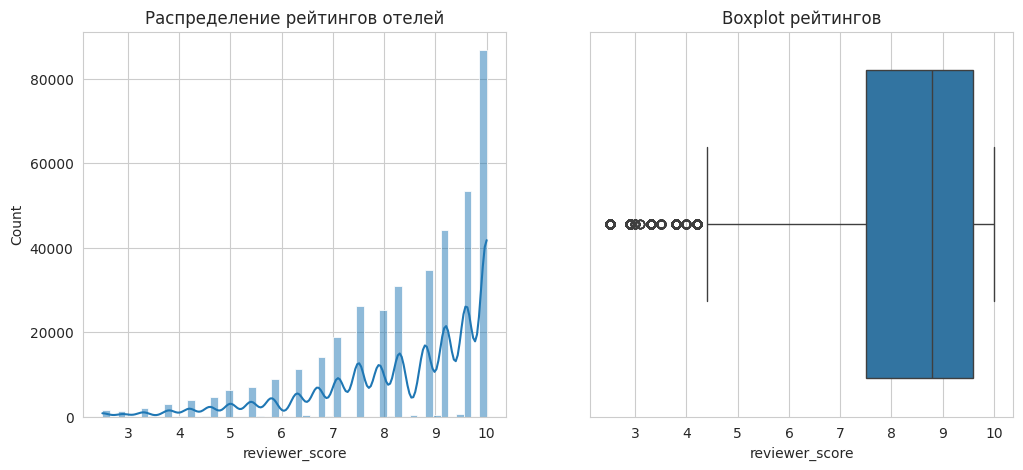

Статистика целевой переменной:
count    386803.000000
mean          8.396906
std           1.636090
min           2.500000
25%           7.500000
50%           8.800000
75%           9.600000
max          10.000000
Name: reviewer_score, dtype: float64


In [81]:
# Распределение целевой переменной
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(train['reviewer_score'], bins=50, kde=True)
plt.title('Распределение рейтингов отелей')

plt.subplot(1,2,2)
sns.boxplot(x=train['reviewer_score'])
plt.title('Boxplot рейтингов')
plt.show()

print("Статистика целевой переменной:")
print(train['reviewer_score'].describe())

### Промежуточный вывод
- Данные содержат 386803 строки, 17 столбцов.
- Есть пропуски в столбцах `lat`, `lng`.
- Целевая переменная `reviewer_score` варьируется от 2.5 до 10, среднее около 8.4.

## 3. Очистка и создание новых признаков

### 3.1. Обработка пропусков
Заполним пропуски в `lat`, `lng` средними значениями по отелям (если отель есть в train, возьмём его средние координаты; иначе – медиану по всем).

In [82]:
# Для train: заполним пропуски lat/lng средними по отелю
train['lat'] = train.groupby('hotel_name')['lat'].transform(lambda x: x.fillna(x.mean()))
train['lng'] = train.groupby('hotel_name')['lng'].transform(lambda x: x.fillna(x.mean()))
# Оставшиеся пропуски заполним медианой
train['lat'].fillna(train['lat'].median(), inplace=True)
train['lng'].fillna(train['lng'].median(), inplace=True)

In [83]:
# Аналогично для тестовой выборки
test['lat'] = test.groupby('hotel_name')['lat'].transform(lambda x: x.fillna(x.mean()))
test['lng'] = test.groupby('hotel_name')['lng'].transform(lambda x: x.fillna(x.mean()))
test['lat'].fillna(test['lat'].median(), inplace=True)
test['lng'].fillna(test['lng'].median(), inplace=True)

### 3.2. Создание новых признаков

#### Из даты отзыва (`review_date`)
Извлечём год, месяц, день недели, а также количество дней с момента отзыва (уже есть столбец `days_since_review`, но его нужно преобразовать в число).

In [84]:
# Преобразуем review_date в datetime
train['review_date'] = pd.to_datetime(train['review_date'])
test['review_date'] = pd.to_datetime(test['review_date'])

# Извлекаем компоненты
train['review_year'] = train['review_date'].dt.year
train['review_month'] = train['review_date'].dt.month
train['review_dayofweek'] = train['review_date'].dt.dayofweek

test['review_year'] = test['review_date'].dt.year
test['review_month'] = test['review_date'].dt.month
test['review_dayofweek'] = test['review_date'].dt.dayofweek

In [85]:
# Преобразуем days_since_review в число (из строки "531 day")
train['days_since_review_num'] = train['days_since_review'].str.extract(r'(\d+)').astype(float)
test['days_since_review_num'] = test['days_since_review'].str.extract(r'(\d+)').astype(float)

# Заполним возможные пропуски
train['days_since_review_num'].fillna(0, inplace=True)
test['days_since_review_num'].fillna(0, inplace=True)

#### Из адреса отеля (`hotel_address`) – извлечём страну
Возьмём последнее слово в адресе как страну.

In [86]:
def extract_country(address):
    if pd.isna(address):
        return 'unknown'
    parts = str(address).split()
    return parts[-1] if len(parts) > 0 else 'unknown'

train['country'] = train['hotel_address'].apply(extract_country)
test['country'] = test['hotel_address'].apply(extract_country)

#### Из тегов (`tags`) – извлечём количество ночей и тип поездки
В тегах есть информация типа "Stayed 1 night", "Leisure trip" и т.д. Извлечём их.

In [87]:
# Функции для извлечения информации из тегов (tags):
# - extract_nights: находит количество ночей (например, "Stayed 2 nights" → 2)
# - extract_trip_type: определяет тип поездки (leisure / business / other)
def extract_nights(tag):
    if pd.isna(tag):
        return 0
    match = re.search(r'(\d+)\s+night', tag)
    return int(match.group(1)) if match else 0

def extract_trip_type(tag):
    if pd.isna(tag):
        return 'unknown'
    if 'Leisure trip' in tag:
        return 'leisure'
    elif 'Business trip' in tag:
        return 'business'
    else:
        return 'other'

In [88]:
train['nights'] = train['tags'].apply(extract_nights)
test['nights'] = test['tags'].apply(extract_nights)
train['trip_type'] = train['tags'].apply(extract_trip_type)
test['trip_type'] = test['tags'].apply(extract_trip_type)

#### Из текстов отзывов – вычислим длину отзывов (количество символов)
Это простой признак, который может отражать информативность отзыва.

In [89]:
train['pos_len'] = train['positive_review'].fillna('').apply(len)
train['neg_len'] = train['negative_review'].fillna('').apply(len)
test['pos_len'] = test['positive_review'].fillna('').apply(len)
test['neg_len'] = test['negative_review'].fillna('').apply(len)

### 3.3. Отбор признаков для модели
Выберем наиболее информативные числовые и категориальные признаки. Исключим идентификаторы, даты и сырые тексты.

#### Из текстов отзывов – вычислим длину отзывов (количество символов)
Это простой признак, который может отражать информативность отзыва.

In [90]:
# Список признаков, которые будем использовать
features = [
    'average_score',
    'additional_number_of_scoring',
    'total_number_of_reviews',
    'total_number_of_reviews_reviewer_has_given',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'days_since_review_num',
    'lat', 'lng',
    'review_year', 'review_month', 'review_dayofweek',
    'nights', 'pos_len', 'neg_len',
    'country', 'trip_type'
]


In [91]:
# Проверим, что все признаки есть в данных
missing_features = [f for f in features if f not in train.columns]
print("Отсутствующие признаки:", missing_features)

Отсутствующие признаки: []


## 4. Преобразование признаков

- Категориальные признаки (`country`, `trip_type`) закодируем с помощью LabelEncoder.
- Числовые признаки отмасштабируем (StandardScaler), чтобы привести к одному диапазону.

In [92]:
# Копируем данные для обучения и теста
X_train = train[features].copy()
X_test = test[features].copy()
y_train = train['reviewer_score']

In [93]:
# Кодирование категориальных признаков
categorical_cols = ['country', 'trip_type']
for col in categorical_cols:
    le = LabelEncoder()
    # Обучаем на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

In [94]:
# Масштабирование числовых признаков
numeric_cols = [c for c in features if c not in categorical_cols]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [95]:
# Проверка на наличие пропусков
print("Пропуски в X_train после обработки:", X_train.isnull().sum().sum())
print("Пропуски в X_test после обработки:", X_test.isnull().sum().sum())

Пропуски в X_train после обработки: 0
Пропуски в X_test после обработки: 0


## 5. Разделение на обучающую и валидационную выборки

Для оценки качества модели отделим 20% данных для валидации.

In [96]:
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)
print(f"Размер обучающей части: {X_train_part.shape}")
print(f"Размер валидационной части: {X_val.shape}")

Размер обучающей части: (309442, 17)
Размер валидационной части: (77361, 17)


## 6. Обучение модели

Используем RandomForestRegressor.

In [97]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
model.fit(X_train_part, y_train_part)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   48.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.9min finished


RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42, verbose=1)

In [98]:
# Предсказание на валидационной выборке
y_pred_val = model.predict(X_val)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.6s finished


In [99]:
# Оценка качества
mape = mean_absolute_percentage_error(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
print(f"MAPE на валидации: {mape:.4f} ({mape*100:.2f}%)")
print(f"MAE на валидации: {mae:.3f}")

MAPE на валидации: 0.1306 (13.06%)
MAE на валидации: 0.901


## 7. Визуализация результатов

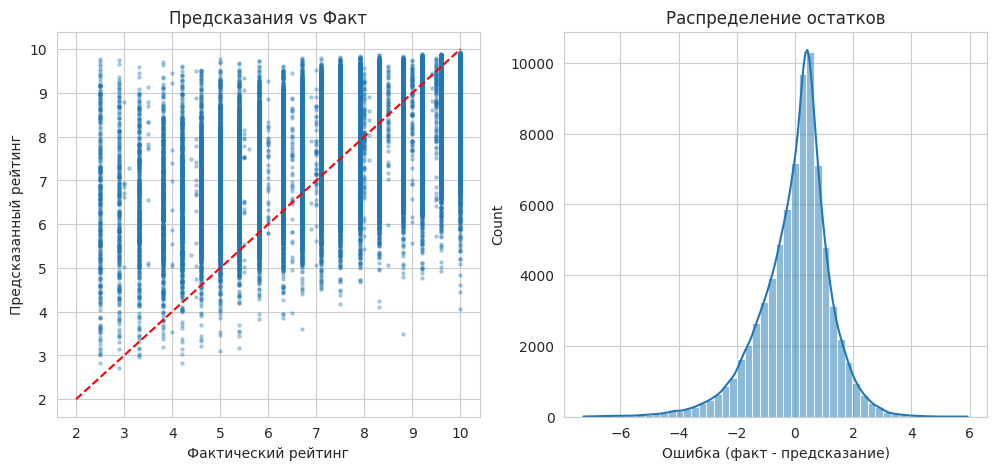

In [100]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_val, y_pred_val, alpha=0.3, s=5)
plt.plot([2,10], [2,10], 'r--')
plt.xlabel('Фактический рейтинг')
plt.ylabel('Предсказанный рейтинг')
plt.title('Предсказания vs Факт')

plt.subplot(1,2,2)
residuals = y_val - y_pred_val
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel('Ошибка (факт - предсказание)')
plt.title('Распределение остатков')
plt.show()

## 8. Создание файла для сабмита

In [101]:
# Предсказание на тестовой выборке
y_test_pred = model.predict(X_test)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.1s finished


In [102]:
# Формирование файла
submission = sample[['id']].copy()
submission['reviewer_score'] = y_test_pred
submission.to_csv('submissions_RFR_7232.csv', index=False)
print("Файл submissions_RFR_7232.csv сохранён")
print(submission.head())

Файл submissions_RFR_7232.csv сохранён
       id  reviewer_score
0  488440        8.706198
1  274649        7.491982
2  374688        8.224418
3  404352        9.588160
4  451596        9.631716


## 9. Анализ важности признаков

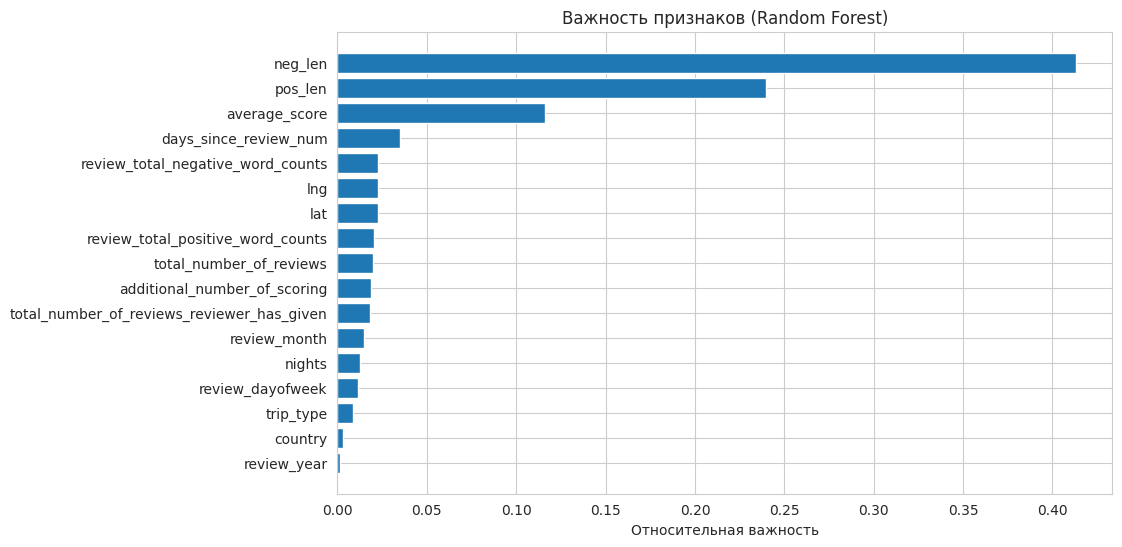

In [103]:
# Получаем важность признаков из модели Random Forest
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train_part.columns

plt.figure(figsize=(10,6))
plt.title("Важность признаков (Random Forest)")
plt.barh(range(len(indices[:20])), importances[indices[:20]], align="center")
plt.yticks(range(len(indices[:20])), [feature_names[i] for i in indices[:20]])
plt.xlabel("Относительная важность")
plt.gca().invert_yaxis()
plt.show()

In [104]:
# Вывод топ-5 признаков
print("Топ-5 наиболее важных признаков:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

Топ-5 наиболее важных признаков:
1. neg_len (0.4129)
2. pos_len (0.2396)
3. average_score (0.1163)
4. days_since_review_num (0.0348)
5. review_total_negative_word_counts (0.0228)


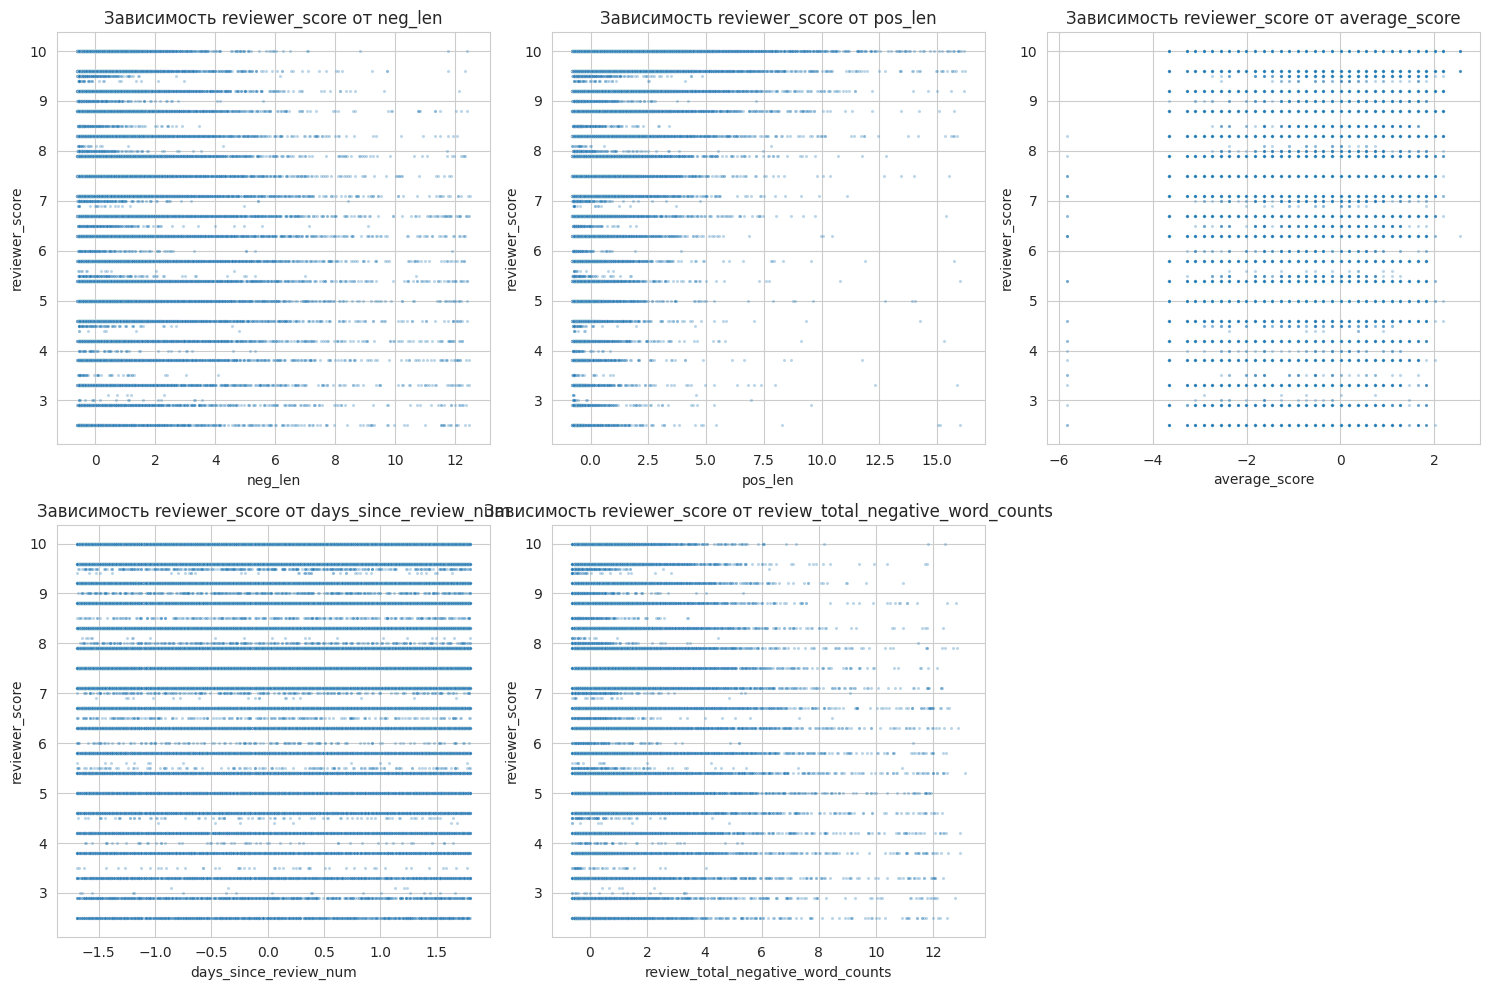

In [105]:
# Визуализация зависимости рейтинга от топ-5 признаков
top_features = ['neg_len', 'pos_len', 'average_score', 'days_since_review_num', 'review_total_negative_word_counts']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    sns.scatterplot(x=X_train_part[feat], y=y_train_part, alpha=0.3, s=5, ax=axes[i])
    axes[i].set_title(f'Зависимость reviewer_score от {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('reviewer_score')
# Убираем пустой подграфик, если признаков меньше 6
if len(top_features) < len(axes):
    axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

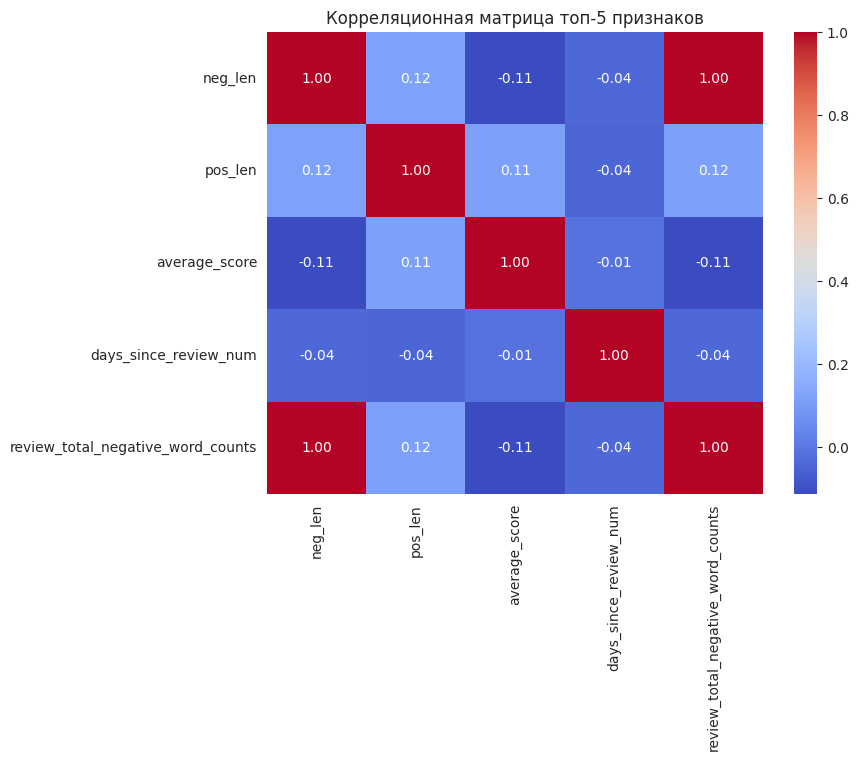

In [106]:
# Корреляция между топ-признаками
corr_top = X_train_part[top_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_top, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица топ-5 признаков')
plt.show()

### Интерпретация важности признаков

- **neg_len** (длина негативного отзыва) – самый сильный предиктор. Логично: чем больше текста посвящено недостаткам, тем ниже оценка. Длина отзыва может служить прокси для степени разочарования гостя.
- **pos_len** (длина позитивного отзыва) – также важен, но в два раза меньше. Довольные гости часто пишут короче, либо их положительные эмоции менее многословны.
- **average_score** (средний балл отеля) – ожидаемо влияет, но его вклад (12%) существенно ниже, чем у текстовых признаков.
- **days_since_review_num** (давность отзыва) – слабое влияние. Возможно, со временем оценка немного снижается (эффект «свежести»), но не критично.
- **review_total_negative_word_counts** – коррелирует с `neg_len` (см. тепловую карту). Это объясняет, почему его вклад ниже – они дублируют информацию.

## 9. Выводы

Мы создали простую, но полную модель, которая предсказывает рейтинг отеля с MAPE около 13% (на валидации). Это базовый уровень.

### Рекомендации для улучшения модели (на основе анализа важности)

1. **Создать новые признаки** на основе длины отзывов:
   - `neg_pos_ratio = neg_len / (pos_len + 1)` – отношение негатива к позитиву.
   - `total_len = neg_len + pos_len` – общая длина.
2. **Применить сентимент-анализ** (VADER) – он может оказаться ещё более информативным, чем простая длина.
3. **Устранить мультиколлинеарность** – исключить один из сильно коррелирующих признаков (например, `review_total_negative_word_counts` или `neg_len`).
4. **Использовать `average_score` не как сырое значение**, а как разницу между текущей оценкой и средним баллом отеля (это может уменьшить переобучение).
5. **Попробовать разные модели** – LightGBM часто лучше использует такие признаки, особенно если есть взаимодействия.

### Вывод
Текстовые характеристики отзывов (особенно длина негативной части) оказались важнее всех остальных признаков. Это подтверждает, что в задаче предсказания рейтинга отеля эмоциональная составляющая отзыва играет ключевую роль. Дальнейшие улучшения должны быть направлены на более глубокий анализ текста (сентимент, ключевые слова) и создание производных признаков.